## HW 1: Sinusoids, Functions, Additive Synthesis (15 points)
For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

In [193]:
import numpy as np
from IPython.display import Audio
import matplotlib.pyplot as plt
import inspect
fs = 44100

### Question 1 - Sinusoids (3 points)
Define the function, **genSine(f, ...)** that construct a sinusoid at frequency `f`.
The arguments should include:  
* amplitude, with default value of 1 (float)
* sample rate, with default value of 44.1kHz (float)
* time in seconds, with default value of 1 (float)
* phase offset, with default value of 0 (float)
    
and will return the numpy array containing the sinusoidal waveform.

Your function must check for appropriate input and handle any errors.
    

In [333]:
# Error Checking module (It's always a hassle)

# Copies original function info to wrapper
from functools import wraps
# function wrapper to check type error
# I'm hoping it lets me communicate errors
# w/o cluttering up the functions w/try-except
# Ironic that it's still so many extra lines to make it work

def expectTypes(*types):
    def wrapper(originalFunc):
        @wraps(originalFunc)
        def modifiedFunc(*args, **kwargs):
            try:
                return originalFunc(*args, **kwargs)
            except TypeError:
                name = originalFunc.__name__
                typeNames = tuple(t.__name__ for t in types)
                raise TypeError(f" function {name}{args} | Expected {name}{typeNames}")
        # returning modifiedFunc for replacement (originalFunc = wrapper(originalFunc))
        return modifiedFunc
    return wrapper

def checkBounds(**argBounds):
    """
    Wrapper that outputs error messages for specified arguments if they are out of bounds
    Only affects defaults if they are changed
    enter args in form
        argName = (start, end)
            # argName: name of arg in function header
            # start, end: bound indices (None for no boundary on that side)
    """
    def wrapper(originalFunc):
        @wraps(originalFunc)
        def modifiedFunc(*args, **kwargs):
            for argName, bound in argBounds.items():
                argValue = getArgValue(argName, originalFunc, *args, **kwargs)
                if argValue is None: # unchanged default
                    continue
                between(argName, argValue, *bound)
            return originalFunc(*args, **kwargs)
        return modifiedFunc
    return  wrapper

def getArgValue(name, fn, *args, **kwargs):
    """
    Helper: get value of argument given name, function,
    and all arguments passed into it
    """
    params = inspect.signature(fn).parameters
    default = params[name].default
    return (args[list(params.keys()).index(name)] if default is inspect._empty
            else kwargs.get(name))

def between(name, value, start=None, end=None):
    """
    Helper function
    Raise error if value if value is not between start and end, exclusive
    """
    if((start is not None and value <= start) 
       or end is not None and value >= end):
        start = "-inf" if start is None else start
        end = "inf" if end is None else end
        raise ValueError(f"{name} ({value}) must be in interval {(start, end)}, exclusive")

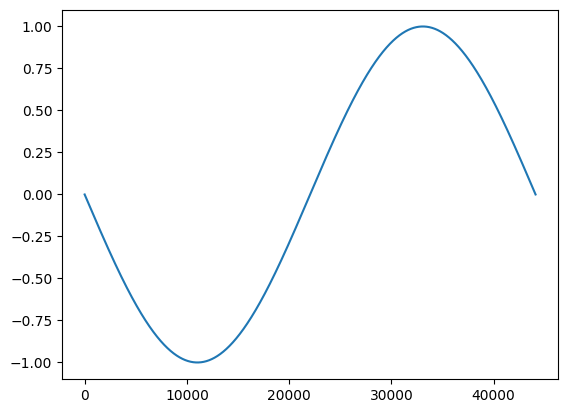

In [339]:
# Value handling
# f = 0, a = 0 produces DC offset as desired
# f < 0, a < 0 produces inverted input as desired
# |f| > fs raises exception
# fs <= 0, t <= 0 raises exception
# phi can be anything
@expectTypes(float, float, float, float, float)
@checkBounds(f=(-fs,fs), fs=(0, None), t=(0, None))
def genSine(f, a=1, fs=44100, t=1, phi=0):
    # checkInput(f, a, fs, t, phi)
    return a*np.sin(2*np.pi*f*np.arange(0,t,1/fs) + phi)

plt.plot(genSine(-1))

In [340]:
# Error example
# Unfortunately, it puts the error at the bottom
genSine("s", t=-1)

TypeError:  function genSine('s',) | Expected genSine('float', 'float', 'float', 'float', 'float')

In [ ]:
# I thought wavetable use was supposed to be more like the code below,
# but I think this is more suitable for a live code setup.

fs = 44100
# 1 Hz sine from 0 to 2pi. fs samples
t = np.arange(0, 1, 1/fs)
wt_sine = np.cos(2*np.pi*t)

f = 440
# f = fs * inc / L, L=fs -> f = inc
s = wt_sine[::f]

# But then, I'd need to continuously read my wavetable
# right now, it's too short.
Audio(s, rate=fs)

### Question 2 - Classical Waveform (5 points)
Define a function, **genWave(freq, t, numHarms=None, A=1, phi=0, fs=44100)**, that will create one of the fundamental waveforms (saw, triangle, or square) built from the combination of sinusoids at integer multiples of a fundamental frequency.  The arguments passed will be as follows:

* freq will be the frequency in Hz (int or float).
* t will be the length of time in seconds (int or float).
* numHarms will be the number of harmonics used. If no value is given (NoneType), you should create the maximum harmonics possible given the sampling rate

The function should return a numpy array. **You may not use existing waveform functions such as those in the `scipy` library.**

Your function must check for appropriate input and handle any errors.

Try to make your function as efficient as you can, but we will not take points off for a long run time. Be mindful by using NumPy functions rather than direct iteration.

*Hint: your function should use your genSine function

**Bonus: Expand this function to create any of the classical waveforms with a new argument "type" specifying which to build.

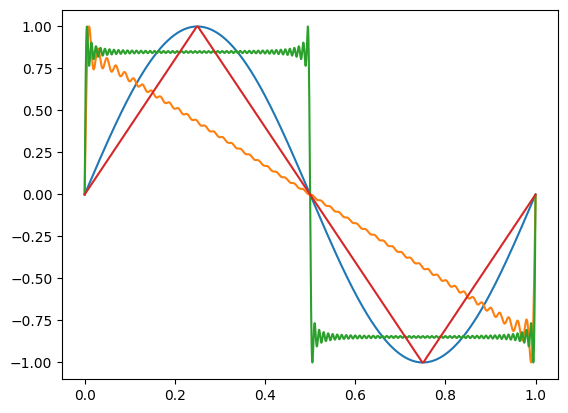

In [341]:
# would move check bounds inside the function in future.
# and also to warn about aliasing happening.
@expectTypes(float, float, int, float, float, float, str)
@checkBounds(f=(-fs, fs), t=(0,None), numHarms=(0, None), fs=(0, None))
def genWave(f, t=1, numHarms=None, A=1, phi=0, fs=fs, type="sine"):

    # max harmonics w/o aliasing is closest to Nyquist w/o going over
    # Also have to take care of numharms being greater than sample rate.
    # This is lazy way
    numHarms = 1 if type=="sine" else min(int(fs*0.5/f), numHarms)
    shape = {
        # frequency and amplitude info
        "sine" : lambda n: (f, 1),
        "saw" : lambda n: (f*n, 1/n),
        "square" : lambda n: (f*(2*n-1), 1/(2*n-1)),
        "triangle" : lambda n: (f*(2*n-1), (-1)**(n-1)/(2*n-1)**2)
    }[type]
    unscaled =  np.sum([genSine(*shape(n), fs, t, phi)
                        for n in range(1, numHarms+1)], axis=0)
    # rescaling here b/c the amplitude calulation is more complex
    return A * (unscaled/max(unscaled))

for type in ("sine", "saw", "square", "triangle"):
    plt.plot(np.arange(0, 1, 1/fs), genWave(1, numHarms=50, type=type))

In [344]:
Audio(genWave(200, 4, 1000, type="saw"), rate=fs)

### Question 3 - Arpeggio (4 points)

Define the function arpegiateFreq(freq, dur), that will create a major scale arpeggio of a given frequency for a given length using your genWave() function. The arguments passed will be as follows:
* freq will be the starting/fundamental frequency in Hz (int or float)
* dur will be the length of time in seconds (int or float)

Reminder: a major scale arpeggio is built from the root, major third, and perfect 5th. You should divide the duration evenly amongst the three notes. 

The function should return a numpy array.

*Hint: your function will use the function(s) you just wrote*

Your function must check for appropriate input and handle any errors

**Bonus: Create a new function called arpegiateNote(scale, dur). Instead of the second input being frequency in Hz, the function should receive a note name like 'C'. You will need to convert this note to frequency. If you want to go the extra mile, make it case sensitive, such that an uppercase 'C' yields a C major arpeggio and lowercase 'c' yields a c minor arpeggio.

In [346]:
@expectTypes(float, float)
@checkBounds(freq=(-fs,fs))
def arpegiateFreq(freq, dur):
    result = np.array([])
    for note in [0, 4, 7]:
       wave = genWave(freq*transratio(note), dur/3, numHarms=100, type="triangle")
       result = np.concatenate((result, wave))
    return result

def transratio(offset):
    """
    offset (int): semitones of desired pitch from reference pitch
    out: frequency of desired pitch (12-TET)
    """
    return 2 ** (offset/12)

Audio(arpegiateFreq(220, 3), rate=fs)

## Error handling tips and edge cases
What should happen if the frequency inputs to our functions would generate frequncies above Nyquist?

What should happen if our time inputs are negative? Or are 0?

What should happen if our frequencies are negative? Or are 0?

You should account for actual coding errors and errors that conceptually do not make sense.

### Section 4 - Using functions and graphing (3 points)
Create a 2 second F major arpeggio in an array named 'myArp'. Play back your audio.

In [347]:
def mtof(midi):
    return 440*transratio(midi-69)
myArp = arpegiateFreq(mtof(53), 2)
Audio(myArp, rate=fs)

Remove every 4th sample of 'myArp', save as a new array, 'skipped, and play back your audio. What happened to the audio?

In [348]:
# Result: The length of the audio decreased by 25% and therefore, given
# f = fs/L (samps/s / samps/cycle), the frequency increased by a factor of 4/3
# a frequency ratio of 4/3 indicates a perfect 4th relation.
# Thus, the new arpeggio is a Bbmaj triad!
# This is confirmed by the audio!
skipped = np.delete(myArp, np.arange(4, myArp.size, 4))
print(skipped.size, myArp.size)
Audio(skipped, rate=fs)

66151 88200


Create a 2 Bb major arpeggio in an array named 'myArp2'. Play back your audio

In [349]:
myArp2 = arpegiateFreq(mtof(58), 2)
Audio(myArp2, rate=fs)

Reverse 'myArp2' and save as a new array, 'reverse'. Play back your audio

In [350]:
reverse = np.flip(myArp2)
Audio(reverse, rate=fs)

Graph your 4 arrays on top of one another. Make sure to label the axis and plot against time. 

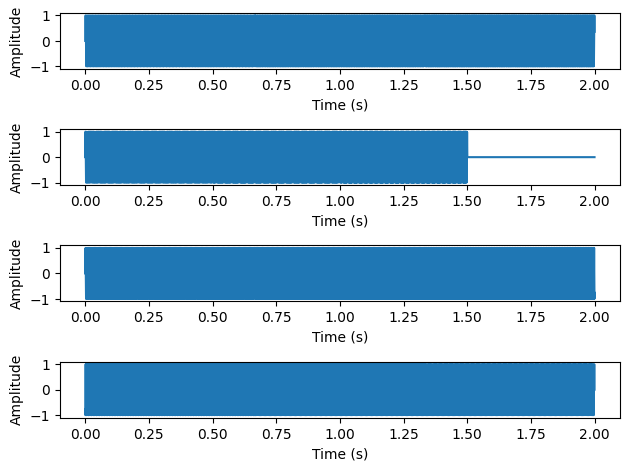

In [351]:
# This is all of them at the full frequency which is just a blur.
t = np.arange(0, 2, 1/fs)
skipped = np.pad(skipped, (0, myArp.size - skipped.size))

def plotAll(ind=myArp.size):
    for i, arr in enumerate((myArp, skipped, myArp2, reverse)):
        plt.subplot(4, 1, i+1)
        plt.plot(t[:ind], arr[:ind])
        plt.ylabel('Amplitude')
        plt.xlabel('Time (s)')
    plt.tight_layout()
    
plotAll()

Create another graph, but this time only plot the first "note" of each array

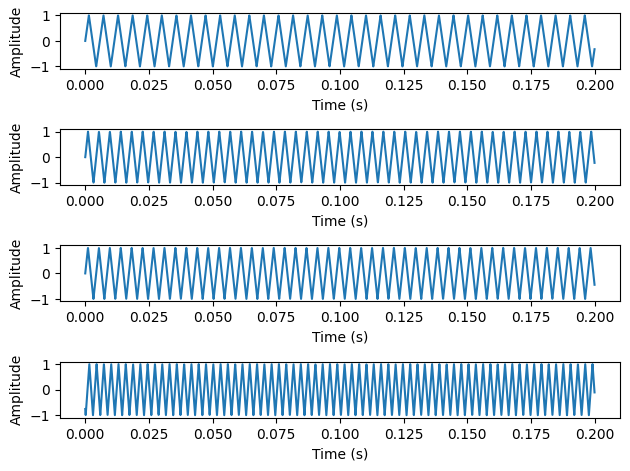

In [352]:
# Plotted to see.
plotAll(int(myArp.size/10))

### GenAI Usage Statement (if applicable)